# Data Wrangling Lab

This notebook walks through the process of cleaning and transforming an automobile dataset.

## Objectives
In this lab, I will:
- identify and handle missing values
- correct data formatting
- standardize data
- normalize data
- bin values into categories
- create indicator variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Import and load the dataset

First, I import the dataset from the source URL, assign column headers, and load it into a pandas dataframe.

In [2]:
import requests

def download(url, filename):
    response = requests.get(url)
    with open(filename, "wb") as f:
        f.write(response.content)

file_path = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
download(file_path, "usedcars.csv")

In [3]:
headers = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location", "wheel-base",
    "length", "width", "height", "curb-weight", "engine-type", "num-of-cylinders",
    "engine-size", "fuel-system", "bore", "stroke", "compression-ratio", "horsepower",
    "peak-rpm", "city-mpg", "highway-mpg", "price"
]

In [4]:
df = pd.read_csv("usedcars.csv", names=headers)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Step 2: Replace missing values

In this dataset, missing values are marked with a question mark (`?`).
To work with them properly in pandas, I replace `?` with `NaN`.

In [5]:
df.replace("?", np.nan, inplace=True)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Step 3: Identify missing values

Now I check which values are missing in the dataframe.
A value of `True` means the data is missing, and `False` means it is present.

In [6]:
missing_data = df.isnull()
missing_data.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 4: Count missing values in each column

This helps me see which columns need to be cleaned and how many missing values each one contains.

In [7]:
for column in missing_data.columns.values.tolist():
    print(column)
    print(missing_data[column].value_counts())
    print("")

symboling
symboling
False    205
Name: count, dtype: int64

normalized-losses
normalized-losses
False    164
True      41
Name: count, dtype: int64

make
make
False    205
Name: count, dtype: int64

fuel-type
fuel-type
False    205
Name: count, dtype: int64

aspiration
aspiration
False    205
Name: count, dtype: int64

num-of-doors
num-of-doors
False    203
True       2
Name: count, dtype: int64

body-style
body-style
False    205
Name: count, dtype: int64

drive-wheels
drive-wheels
False    205
Name: count, dtype: int64

engine-location
engine-location
False    205
Name: count, dtype: int64

wheel-base
wheel-base
False    205
Name: count, dtype: int64

length
length
False    205
Name: count, dtype: int64

width
width
False    205
Name: count, dtype: int64

height
height
False    205
Name: count, dtype: int64

curb-weight
curb-weight
False    205
Name: count, dtype: int64

engine-type
engine-type
False    205
Name: count, dtype: int64

num-of-cylinders
num-of-cylinders
False    205
Nam

## Step 5: Handle missing data

For numerical columns, I replace missing values with the column mean.

For categorical columns, I replace missing values with the most frequent category.

For rows missing `price`, I remove them because `price` is an important target value in the dataset.

In [35]:
avg_norm_loss = df["normalized-losses"].astype("float").mean(axis=0)
print("Average normalized-losses:", avg_norm_loss)

df["normalized-losses"] = df["normalized-losses"].replace(np.nan, avg_norm_loss)

Average normalized-losses: 122.0


In [36]:
avg_bore = df["bore"].astype("float").mean(axis=0)
print("Average bore:", avg_bore)

df["bore"] = df["bore"].replace(np.nan, avg_bore)

Average bore: 3.33069156704042


## Question 1: Replace missing values in `stroke`

Here, I calculate the mean of the `stroke` column and use it to replace missing values.

In [37]:
avg_stroke = df["stroke"].astype("float").mean(axis=0)
print("Average stroke:", avg_stroke)

df["stroke"] = df["stroke"].replace(np.nan, avg_stroke)

Average stroke: 3.2568740872750674


In [38]:
avg_horsepower = df["horsepower"].astype("float").mean(axis=0)
print("Average horsepower:", avg_horsepower)

df["horsepower"] = df["horsepower"].replace(np.nan, avg_horsepower)

Average horsepower: 103.40298507462687


In [39]:
avg_peakrpm = df["peak-rpm"].astype("float").mean(axis=0)
print("Average peak-rpm:", avg_peakrpm)

df["peak-rpm"] = df["peak-rpm"].replace(np.nan, avg_peakrpm)

Average peak-rpm: 5117.665367742568


## Replace missing values in `num-of-doors`

Since this is a categorical column, I use the most common value instead of a mean.

In [13]:
df["num-of-doors"].value_counts()

,count
num-of-doors,
four,114
two,89


In [41]:
df["num-of-doors"] = df["num-of-doors"].replace(np.nan, "four")

## Drop rows with missing `price`

Because `price` is essential for analysis, rows with missing price values are removed.

In [15]:
df.dropna(subset=["price"], axis=0, inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Step 6: Correct data format

Next, I check the data types of each column and convert them where needed.
Some columns are stored as text but should actually be numeric.

In [16]:
df.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [44]:
df[["bore", "stroke"]] = df[["bore", "stroke"]].astype("float")
df[["normalized-losses"]] = df[["normalized-losses"]].astype("int")
df[["price"]] = df[["price"]].astype("float")
df[["peak-rpm"]] = df[["peak-rpm"]].astype("float")
df[["horsepower"]] = df[["horsepower"]].astype("float")

In [45]:
df.dtypes

,0
symboling,int64
normalized-losses,int64
make,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64
length,float64
width,float64


## Step 7: Data standardization

Standardization changes data into a common format.

In this case, fuel consumption values are converted from miles per gallon (mpg) to litres per 100 kilometres (L/100km) using the formula:

`L/100km = 235 / mpg`

In [19]:
df["city-L/100km"] = 235 / df["city-mpg"]
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,27,13495.0,11.190476
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,27,16500.0,11.190476
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000.0,19,26,16500.0,12.368421
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500.0,24,30,13950.0,9.791667
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500.0,18,22,17450.0,13.055556


## Question 2: Convert `highway-mpg` to `highway-L/100km`

Here, I convert the highway fuel consumption values and rename the column to reflect the new unit.

In [20]:
df["highway-mpg"] = 235 / df["highway-mpg"]
df.rename(columns={"highway-mpg": "highway-L/100km"}, inplace=True)

df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,8.703704,13495.0,11.190476
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,8.703704,16500.0,11.190476
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000.0,19,9.038462,16500.0,12.368421
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500.0,24,7.833333,13950.0,9.791667
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500.0,18,10.681818,17450.0,13.055556


## Step 8: Data normalization

Normalization scales values into a similar range, usually from 0 to 1.

I do this by dividing each value by the maximum value in the column.

In [21]:
df["length"] = df["length"] / df["length"].max()
df["width"] = df["width"] / df["width"].max()

## Question 3: Normalize the `height` column

To normalize the `height` column, I divide each height value by the maximum height in the dataset.

In [22]:
df["height"] = df["height"] / df["height"].max()
df[["length", "width", "height"]].head()

,length,width,height
0,0.811148,0.890278,0.816054
1,0.811148,0.890278,0.816054
2,0.822681,0.909722,0.876254
3,0.848630,0.919444,0.908027
4,0.848630,0.922222,0.908027


## Step 9: Binning

Binning groups continuous numerical values into categories.

In this lab, I bin horsepower values into three categories:
- Low
- Medium
- High

In [23]:
df["horsepower"] = df["horsepower"].astype(int, copy=True)

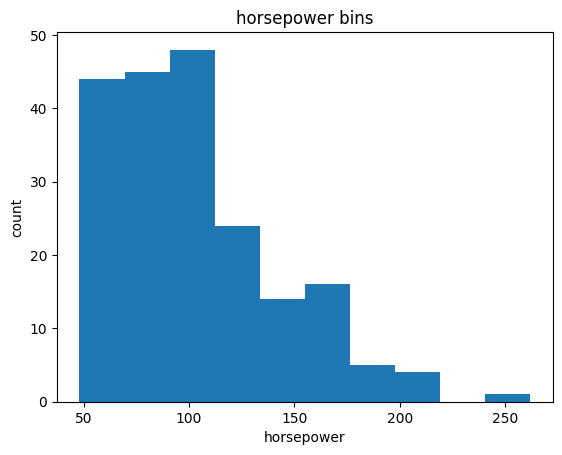

In [24]:
plt.hist(df["horsepower"])
plt.xlabel("horsepower")
plt.ylabel("count")
plt.title("horsepower bins")
plt.show()

In [25]:
bins = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)
group_names = ["Low", "Medium", "High"]

df["horsepower-binned"] = pd.cut(df["horsepower"], bins, labels=group_names, include_lowest=True)
df[["horsepower", "horsepower-binned"]].head(20)

,horsepower,horsepower-binned
0,111,Low
1,111,Low
2,154,Medium
3,102,Low
4,115,Low
5,110,Low
6,110,Low
7,110,Low
8,140,Medium
9,101,Low


In [26]:
df["horsepower-binned"].value_counts()

,count
horsepower-binned,
Low,153
Medium,43
High,5


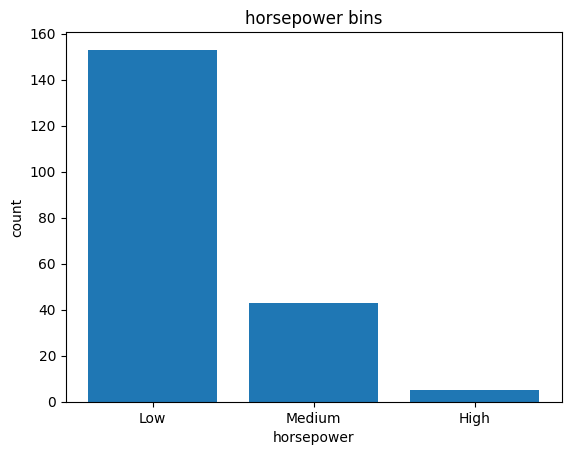

In [27]:
plt.bar(group_names, df["horsepower-binned"].value_counts())
plt.xlabel("horsepower")
plt.ylabel("count")
plt.title("horsepower bins")
plt.show()

## Step 10: Indicator variables

Indicator variables, also called dummy variables, convert categorical values into numerical columns.

This is useful because many models work better with numeric data than text categories.

In [28]:
dummy_variable_1 = pd.get_dummies(df["fuel-type"])
dummy_variable_1.head()

,diesel,gas
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


In [29]:
dummy_variable_1.rename(columns={"gas": "fuel-type-gas", "diesel": "fuel-type-diesel"}, inplace=True)
dummy_variable_1.head()

,fuel-type-diesel,fuel-type-gas
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


In [30]:
df = pd.concat([df, dummy_variable_1], axis=1)
df.drop("fuel-type", axis=1, inplace=True)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,horsepower-binned,fuel-type-diesel,fuel-type-gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111,5000.0,21,8.703704,13495.0,11.190476,Low,False,True
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111,5000.0,21,8.703704,16500.0,11.190476,Low,False,True
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154,5000.0,19,9.038462,16500.0,12.368421,Medium,False,True
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102,5500.0,24,7.833333,13950.0,9.791667,Low,False,True
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115,5500.0,18,10.681818,17450.0,13.055556,Low,False,True


## Question 4: Create indicator variables for `aspiration`

Now I create dummy variables for the `aspiration` column.

In [31]:
dummy_variable_2 = pd.get_dummies(df["aspiration"])
dummy_variable_2.head()

,std,turbo
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False


## Question 5: Merge the new dataframe into the original dataframe and drop the original `aspiration` column

This adds the new indicator columns to the dataframe and removes the original categorical column.

In [32]:
df = pd.concat([df, dummy_variable_2], axis=1)
df.drop("aspiration", axis=1, inplace=True)
df.head()

,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,horsepower-binned,fuel-type-diesel,fuel-type-gas,std,turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,5000.0,21,8.703704,13495.0,11.190476,Low,False,True,True,False
1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,5000.0,21,8.703704,16500.0,11.190476,Low,False,True,True,False
2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,0.909722,...,5000.0,19,9.038462,16500.0,12.368421,Medium,False,True,True,False
3,2,164,audi,four,sedan,fwd,front,99.8,0.848630,0.919444,...,5500.0,24,7.833333,13950.0,9.791667,Low,False,True,True,False
4,2,164,audi,four,sedan,4wd,front,99.4,0.848630,0.922222,...,5500.0,18,10.681818,17450.0,13.055556,Low,False,True,True,False


## Step 11: Save the cleaned dataset

Finally, I save the cleaned dataframe as a new CSV file.

In [33]:
df.to_csv("clean_df.csv", index=False)

## Conclusion

In this lab, I cleaned and transformed the automobile dataset by:
- replacing missing values
- correcting data types
- standardizing units
- normalizing numerical values
- binning horsepower into categories
- creating indicator variables for categorical data

The cleaned dataset was saved as `clean_df.csv`.